# Logarithm transformation


In [23]:
import numpy as np
import pandas as pd

# for plotting
import matplotlib.pyplot as plt

# for Q-Q plots
import scipy.stats as stats

# the dataset for the demo
from sklearn.datasets import fetch_california_housing

In [24]:
# load the California House price data from Scikit-learn
X, y = fetch_california_housing(return_X_y=True, as_frame=True)

# display top 5 rows
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


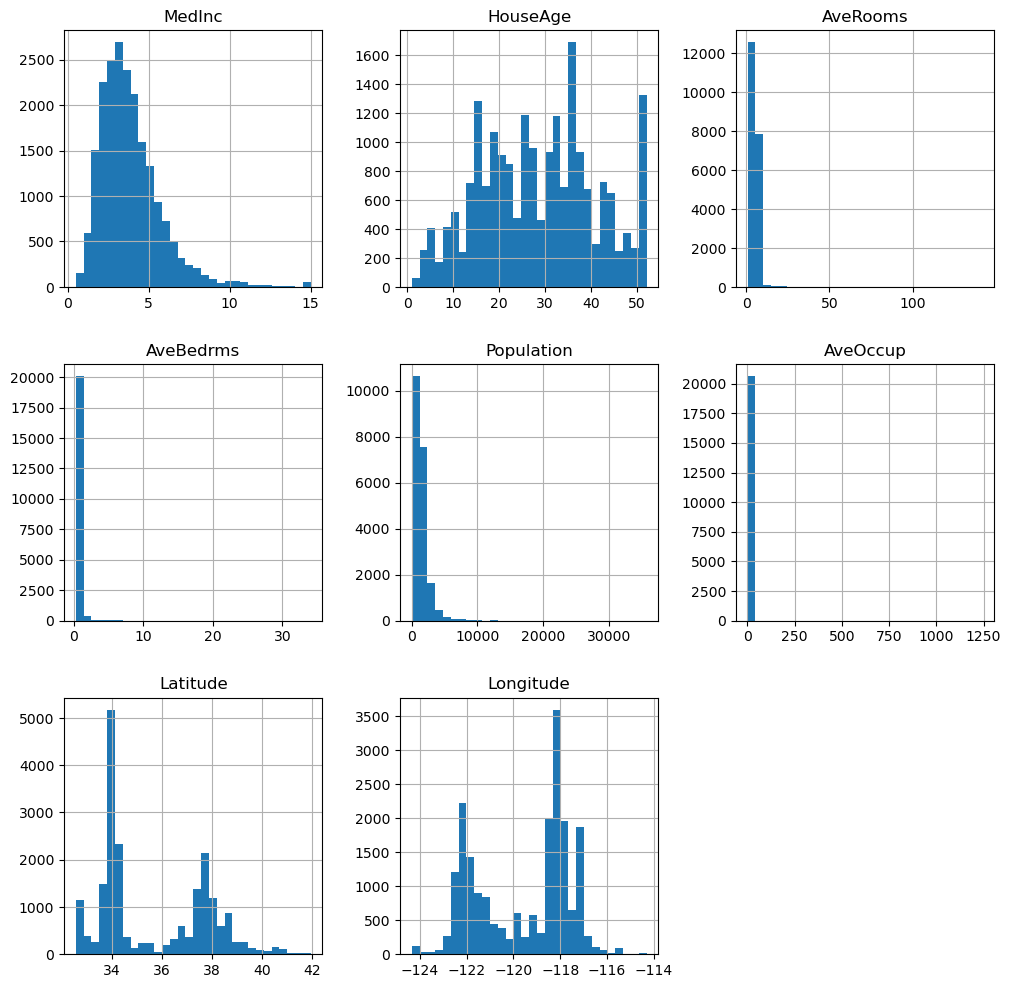

In [25]:
# Plot histograms to inspect variable distributions

X.hist(bins=30, figsize=(12, 12))
plt.show()

In [26]:
# Plot histogram and Q-Q plots to explore the variable distribution


def diagnostic_plots(df, variable):

    # function to plot a histogram and a Q-Q plot
    # side by side, for a certain variable

    plt.figure(figsize=(15, 6))

    # histogram
    plt.subplot(1, 2, 1)
    df[variable].hist(bins=30)
    plt.title(f"Histogram of {variable}")

    # q-q plot
    plt.subplot(1, 2, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.title(f"Q-Q plot of {variable}")

    plt.show()

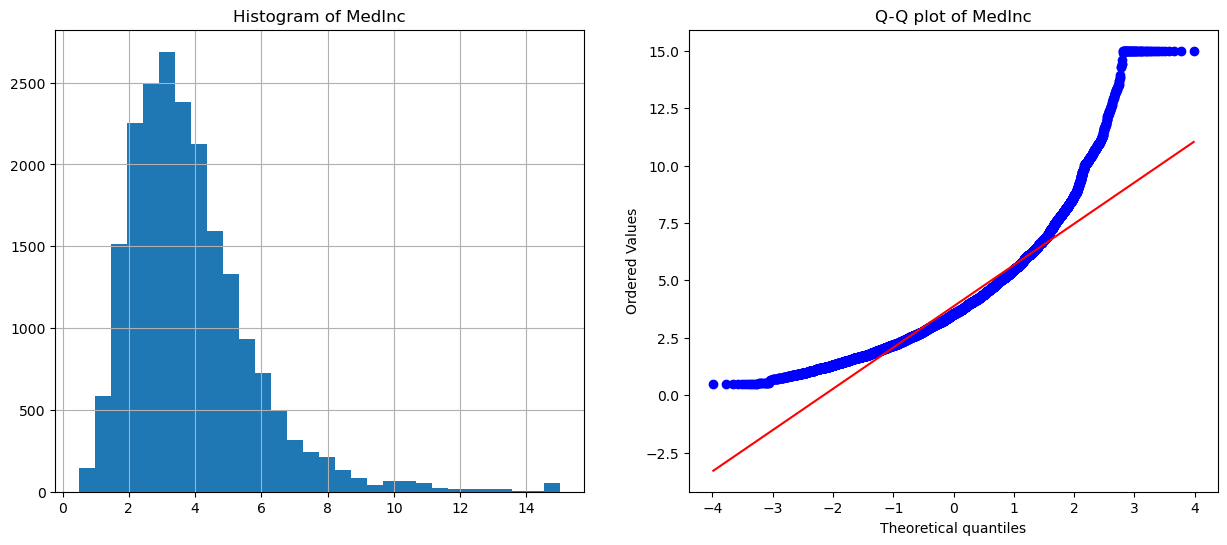

In [27]:
# Check function output

diagnostic_plots(X, "MedInc")

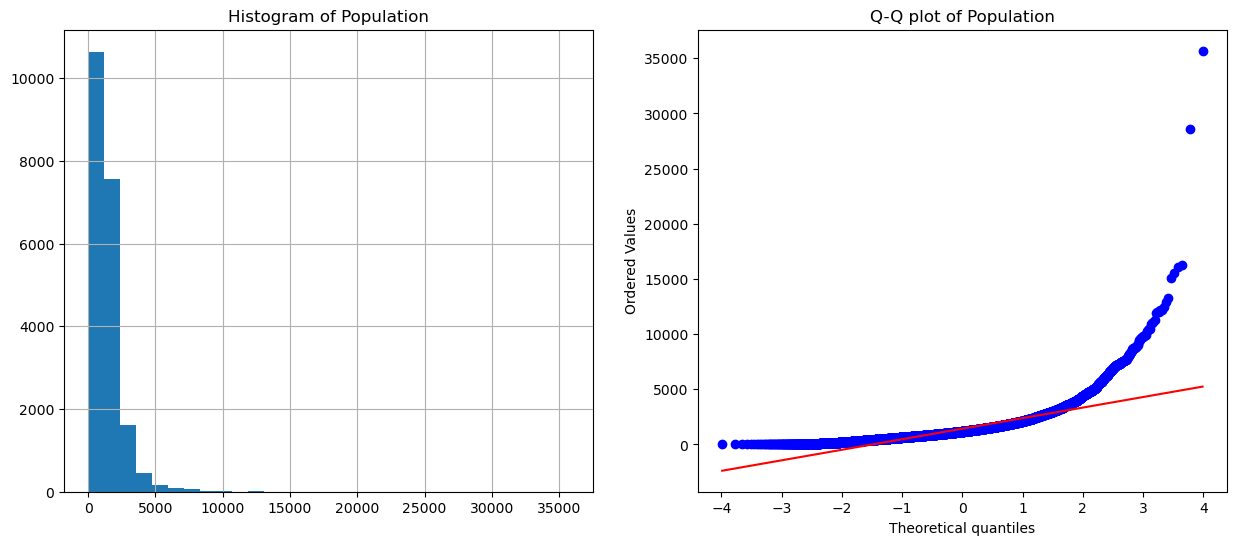

In [28]:
diagnostic_plots(X, "Population")

# Logarithmic transformation with NumPy

In [29]:
# make a copy of the dataframe where we will store the modified
# variables

X_tf = X.copy()

In [30]:
# list with the variables to transform

variables = ["MedInc", "AveRooms", "AveBedrms", "Population"]

In [31]:
# apply log to a set of variables

X_tf[variables] = np.log(X[variables])

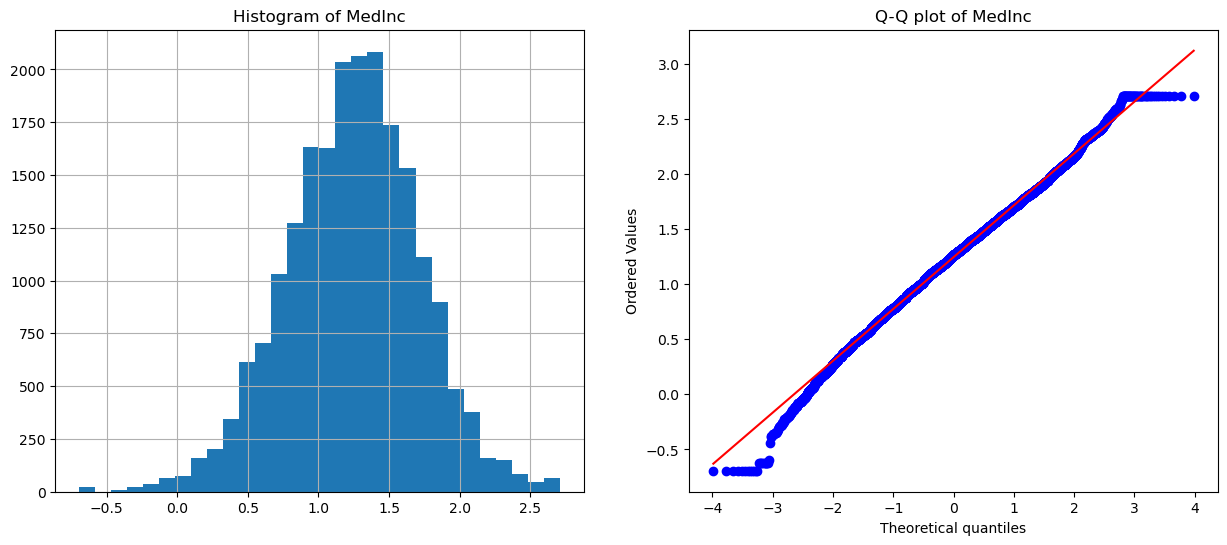

In [32]:
# use diagnostic plot function to corroborate variable transformation

diagnostic_plots(X_tf, "MedInc")

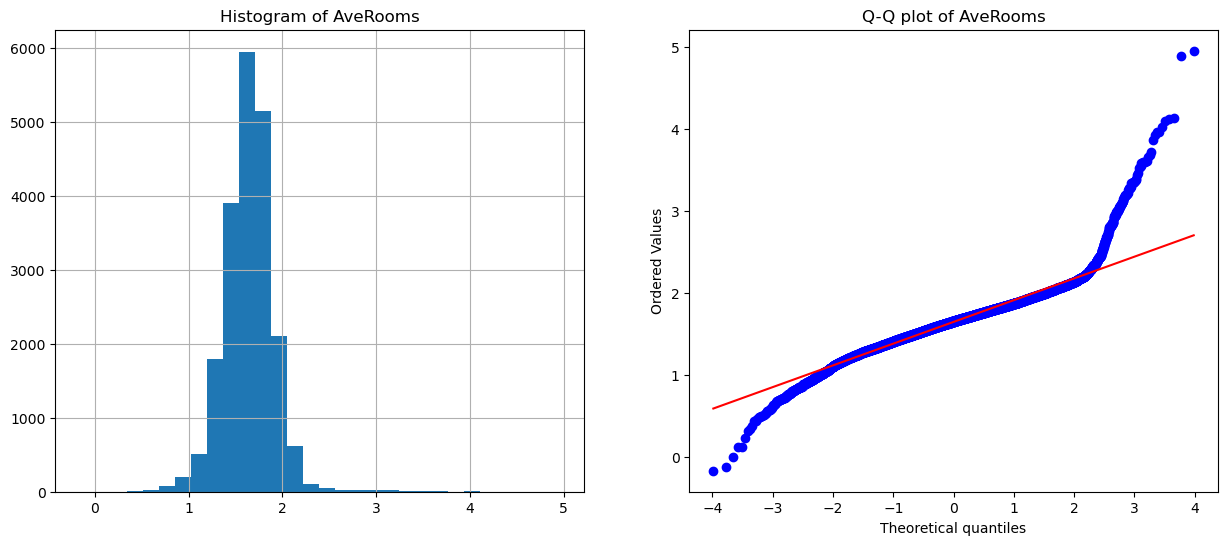

In [33]:
diagnostic_plots(X_tf, "AveRooms")

# Logarithm plus constant

If you want to add a constant to the variables, say because some of their values are 0 or negative, this is how to do it.

In [34]:
# make a copy of original data

X_tf = X.copy()

In [35]:
import numpy as np

X_tf[variables] = np.log1p(X_tf[variables])


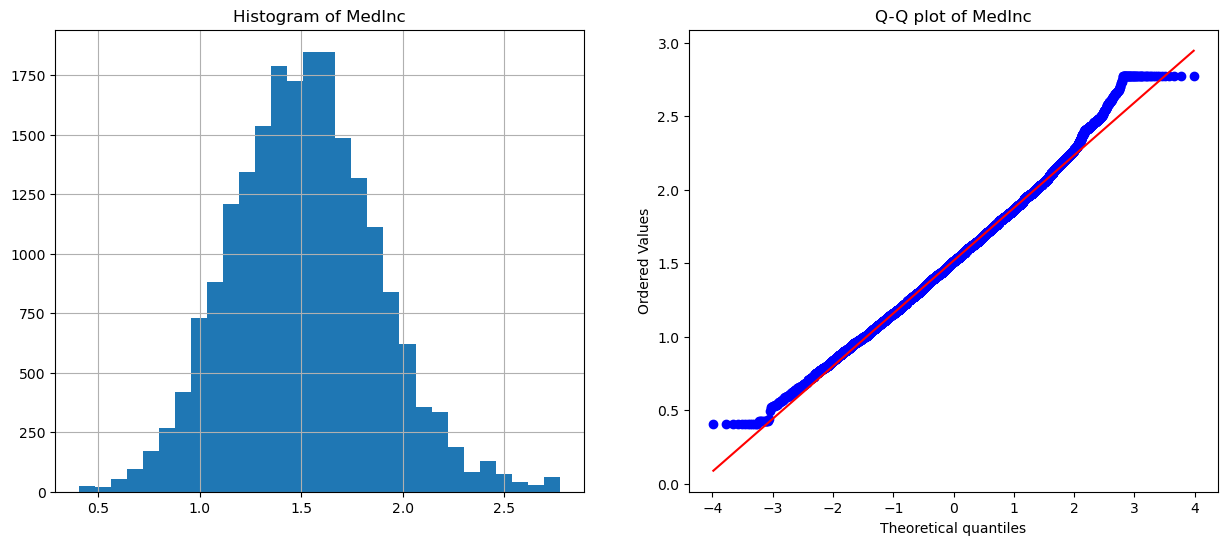

In [36]:
# use diagnostic plot function to corroborate variable transformation

diagnostic_plots(X_tf, "MedInc")

# Reciprocal transformation


In [37]:
import numpy as np
import pandas as pd

# for plotting
import matplotlib.pyplot as plt

# for Q-Q plots
import scipy.stats as stats

# the dataset for the demo
from sklearn.datasets import fetch_california_housing

In [38]:
data = fetch_california_housing()

print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [39]:
# load the California House price data from Scikit-learn
X, y = fetch_california_housing(return_X_y=True, as_frame=True)

# display top 5 rows
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [40]:
# Plot histogram and Q-Q plots to explore the variable distribution


def diagnostic_plots(df, variable):

    # function to plot a histogram and a Q-Q plot
    # side by side, for a certain variable

    plt.figure(figsize=(15, 6))

    # histogram
    plt.subplot(1, 2, 1)
    df[variable].hist(bins=30)
    plt.title(f"Histogram of {variable}")

    # q-q plot
    plt.subplot(1, 2, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.title(f"Q-Q plot of {variable}")

    plt.show()

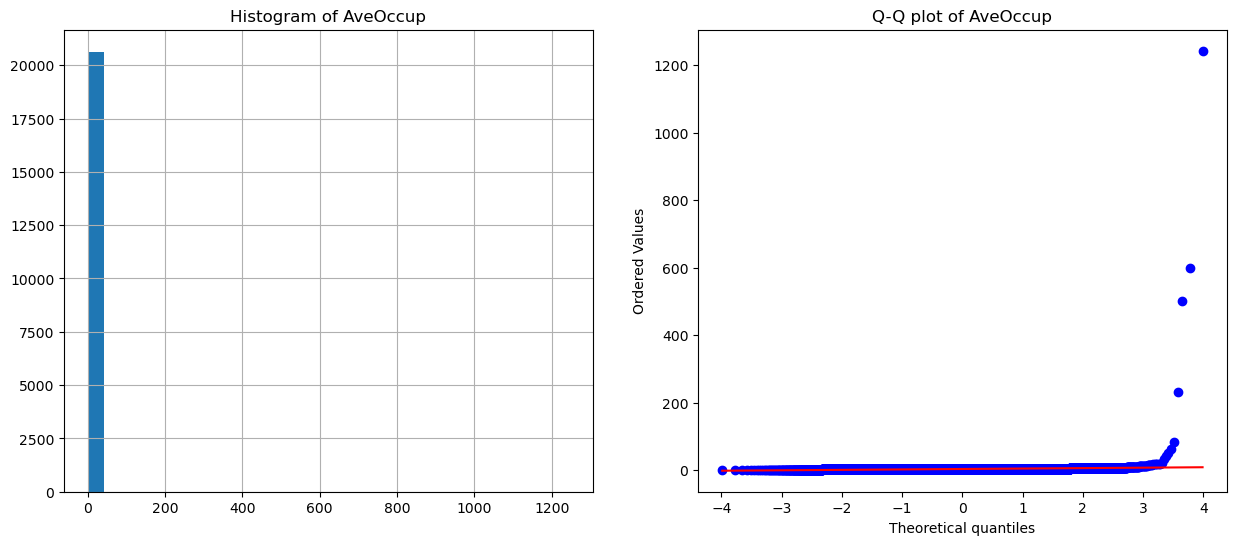

In [41]:
# Check function output

# AveOccup = average number of household members (number of people per household)
# AveOccup = number of members / number of houses

diagnostic_plots(X, "AveOccup")

# Reciprocal transformation with NumPy

In [42]:
# make a copy of the dataframe where we will store the modified
# variables

X_tf = X.copy()

In [43]:
X_tf["AveOccup"] = 1 / X_tf["AveOccup"]


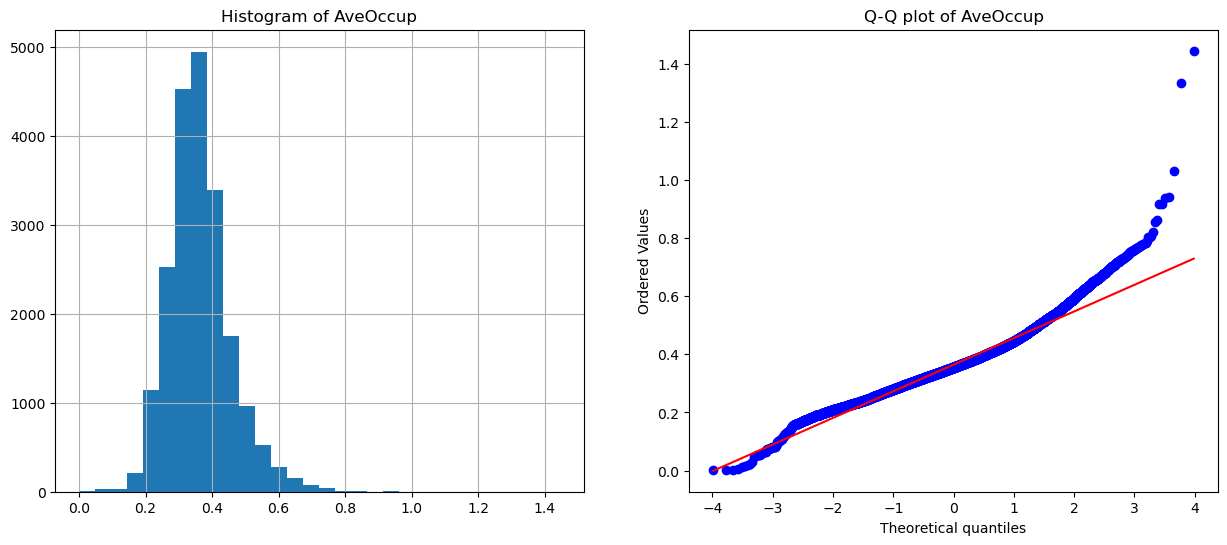

In [44]:
# use diagnostic plot function to corroborate variable transformation

# AveOccup = number of households per number of people)
# AveOccup = number of houses / number of people

diagnostic_plots(X_tf, "AveOccup")

# Square-root transformation



In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [46]:
# create dataframe
df = pd.DataFrame()

# draw samples from a poisson distribution
df["counts1"] = stats.poisson.rvs(mu=3, size=10000)
df["counts2"] = stats.poisson.rvs(mu=2, size=10000)

# display top rows
df.head()

,counts1,counts2
0,1,1
1,4,0
2,2,1
3,0,2
4,2,1


In [47]:
def diagnostic_plots(df, variable):

    # function to plot a bar plot and a Q-Q plot
    # side by side, for a certain variable

    plt.figure(figsize=(15, 6))

    # histogram
    plt.subplot(1, 2, 1)
    df[variable].value_counts().sort_index().plot.bar()
    plt.title(f"Bar plot of {variable}")

    # q-q plot
    plt.subplot(1, 2, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.title(f"Q-Q plot of {variable}")

    plt.show()

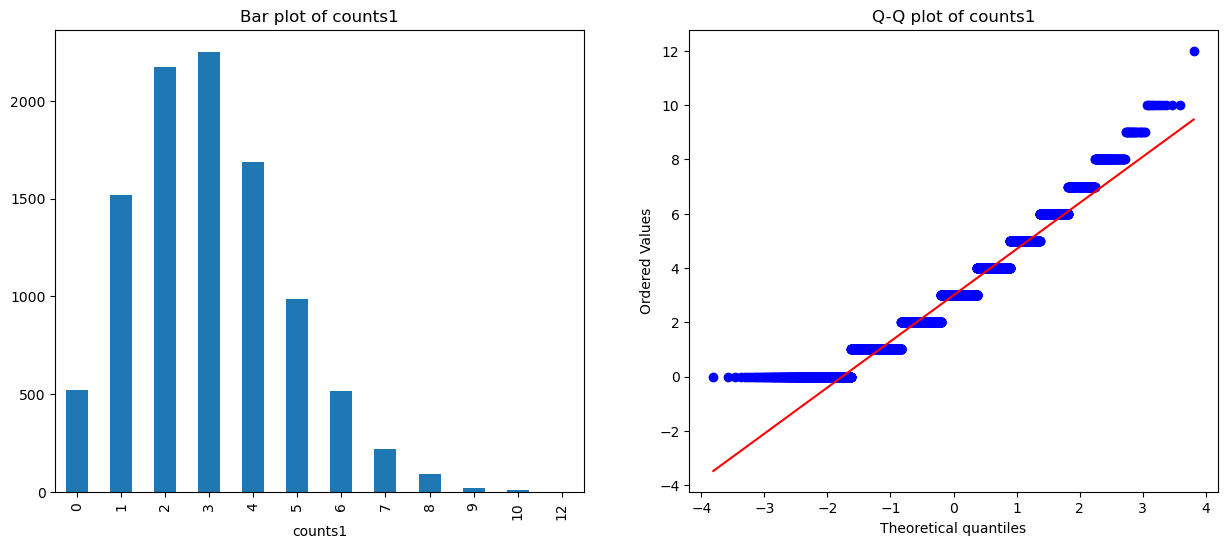

In [48]:
diagnostic_plots(df, "counts1")

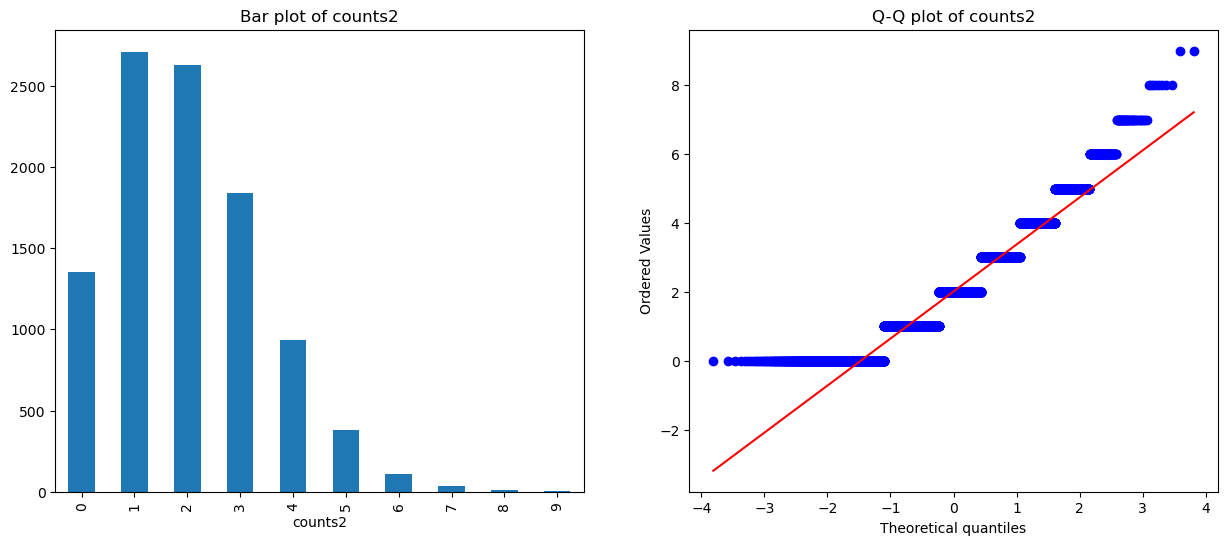

In [49]:
diagnostic_plots(df, "counts2")

# Square root with NumPy

In [50]:
# make a copy of the dataframe

df_tf = df.copy()

In [51]:
import numpy as np

df_tf[["counts1", "counts2"]] = np.sqrt(df_tf[["counts1", "counts2"]])
df_tf[["counts1", "counts2"]] = np.round(df_tf[["counts1", "counts2"]], 2)


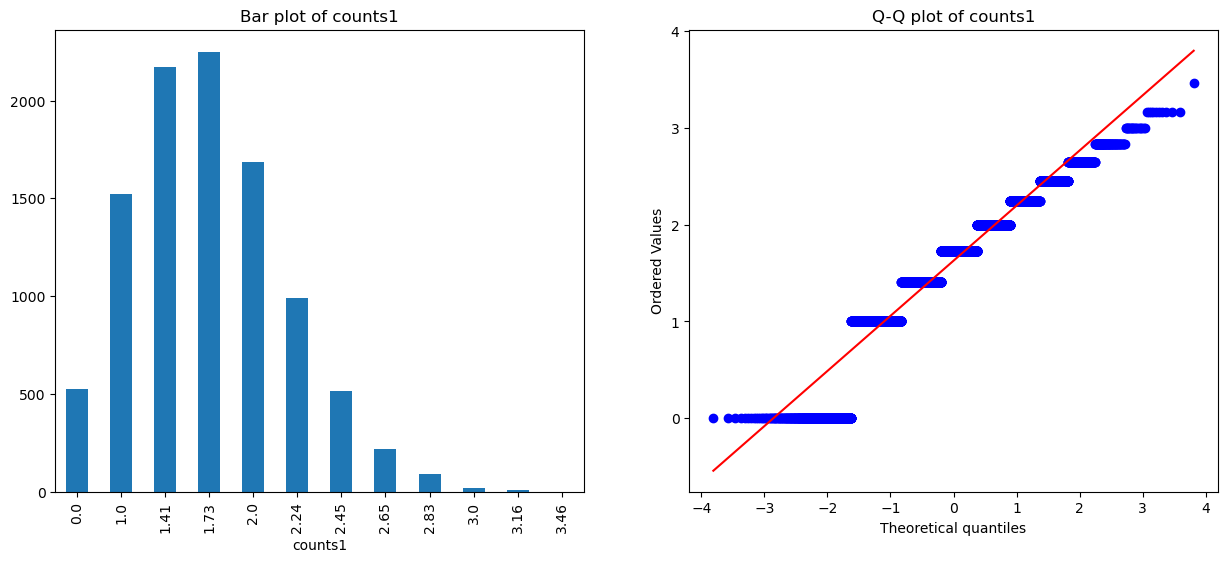

In [52]:
diagnostic_plots(df_tf, "counts1")

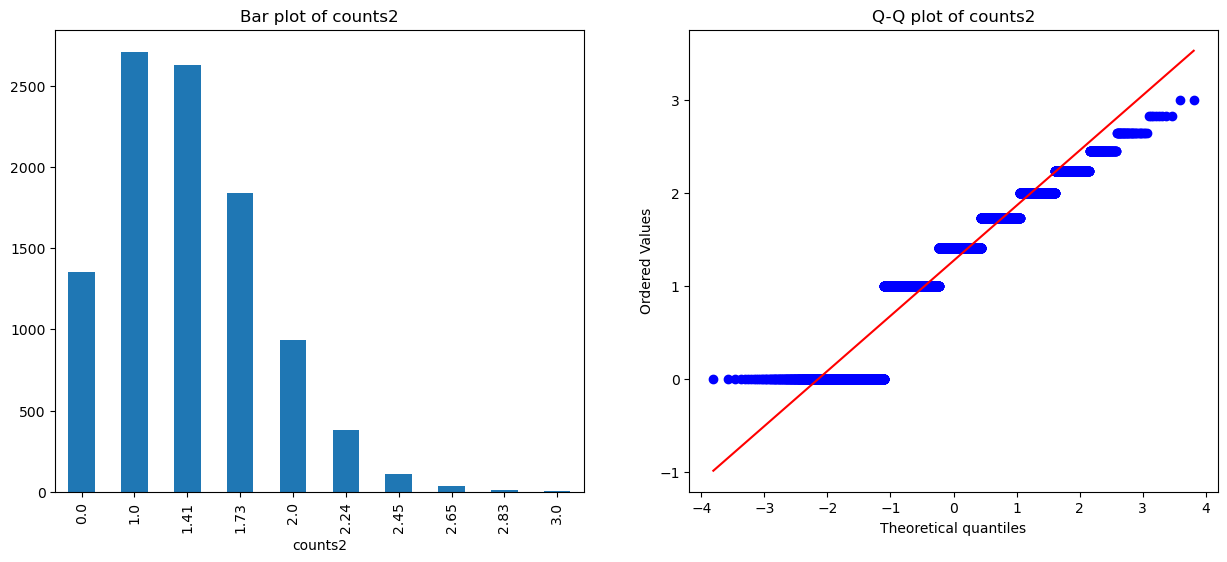

In [53]:
diagnostic_plots(df_tf, "counts2")

# Power transformation


In [54]:
import numpy as np
import pandas as pd

# for plotting
import matplotlib.pyplot as plt

# for Q-Q plots
import scipy.stats as stats

# the dataset for the demo
from sklearn.datasets import fetch_california_housing

In [55]:
# load the California House price data from Scikit-learn
X, y = fetch_california_housing(return_X_y=True, as_frame=True)

# display top 5 rows
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [56]:
# Plot histogram and Q-Q plots to explore the variable distribution


def diagnostic_plots(df, variable):

    # function to plot a histogram and a Q-Q plot
    # side by side, for a certain variable

    plt.figure(figsize=(15, 6))

    # histogram
    plt.subplot(1, 2, 1)
    df[variable].hist(bins=30)
    plt.title(f"Histogram of {variable}")

    # q-q plot
    plt.subplot(1, 2, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.title(f"Q-Q plot of {variable}")

    plt.show()

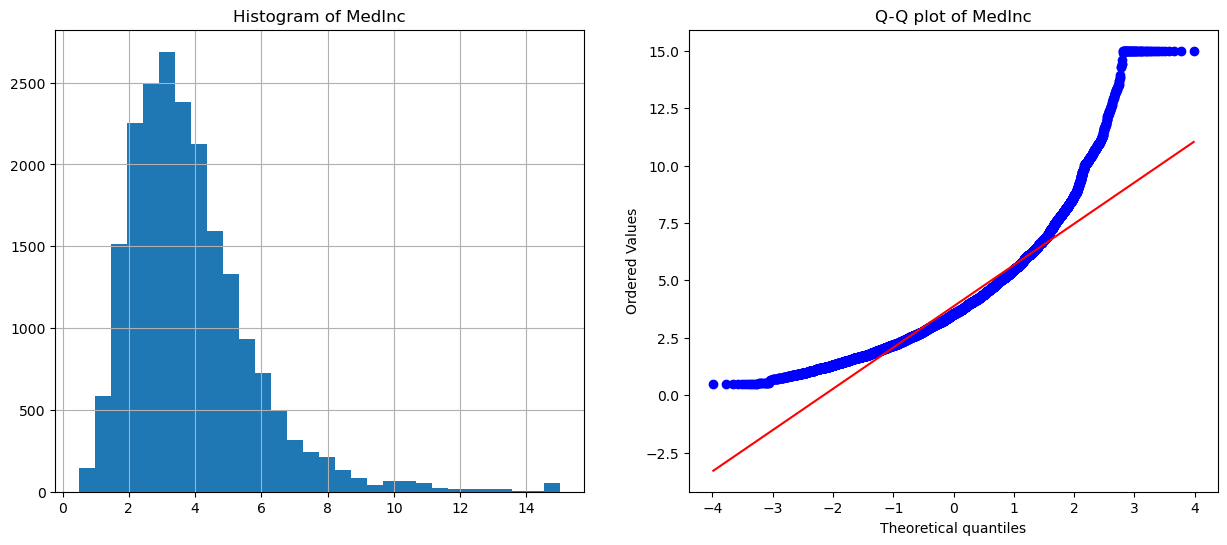

In [57]:
# check original distribution (not included in this recipe of book)

diagnostic_plots(X, "MedInc")

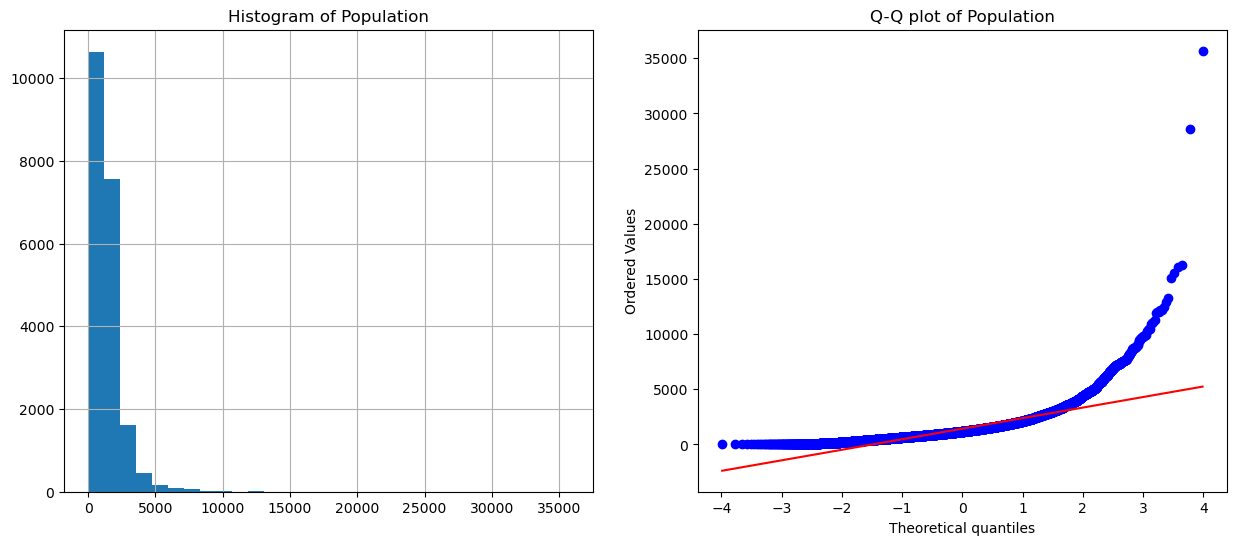

In [58]:
diagnostic_plots(X, "Population")

# Power transformation with NumPy

In [59]:
# make a copy of the dataframe where we will store the modified
# variables

X_tf = X.copy()

In [60]:
# make a list with the variables to transform

variables = ["MedInc", "Population"]

In [61]:
X_tf[variables] = X_tf[variables] ** 0.3


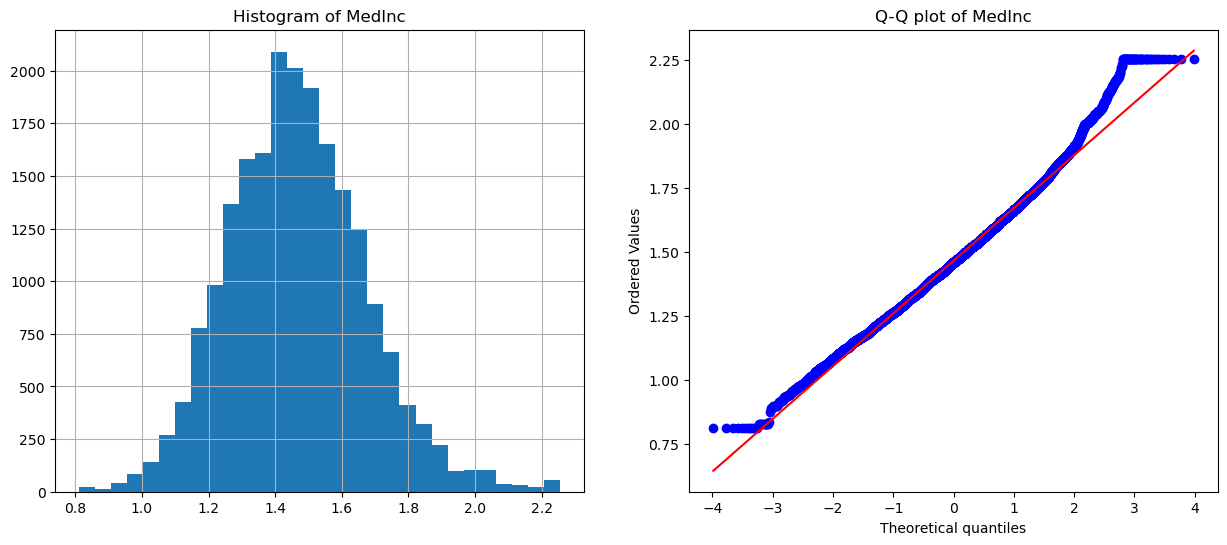

In [62]:
# check the distribution of the transformed variable

diagnostic_plots(X_tf, "MedInc")

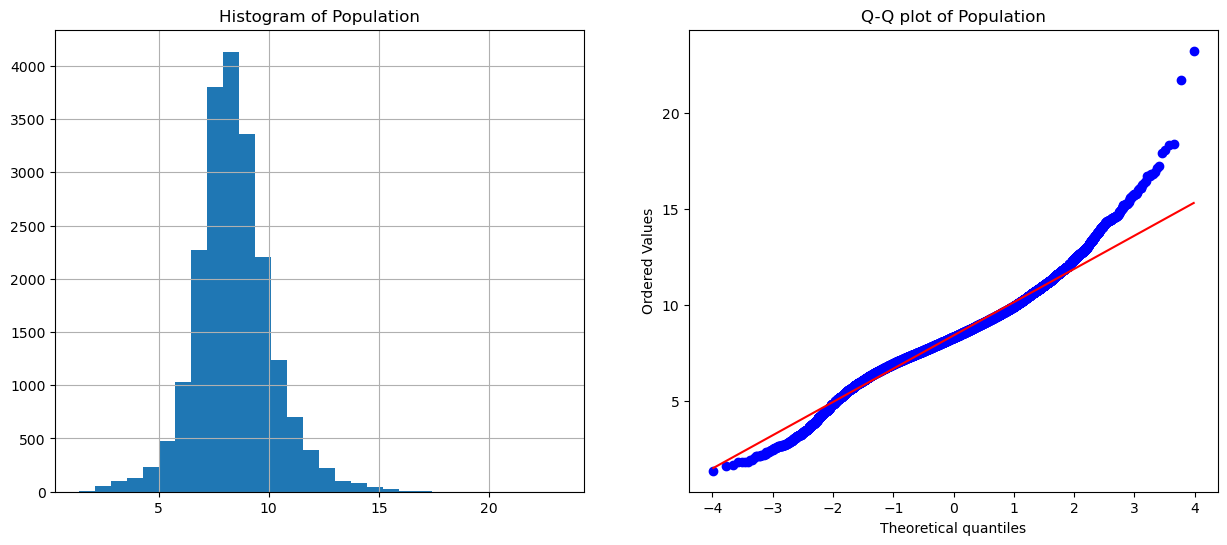

In [63]:
diagnostic_plots(X_tf, "Population")

# Box-Cox transformation



In [64]:
import pandas as pd

# for plotting
import matplotlib.pyplot as plt

# for Q-Q plots
import scipy.stats as stats

# the dataset for the demo
from sklearn.datasets import fetch_california_housing

In [65]:
# load the California House price data from Scikit-learn
X, y = fetch_california_housing(return_X_y=True, as_frame=True)

# drop lat and lon
X.drop(labels=["Latitude", "Longitude"], axis=1, inplace=True)

# display top 5 rows
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467


In [66]:
# Plot histogram and Q-Q plots to explore the variable distribution


def diagnostic_plots(df, variable):

    # function to plot a histogram and a Q-Q plot
    # side by side, for a certain variable

    plt.figure(figsize=(15, 6))

    # histogram
    plt.subplot(1, 2, 1)
    df[variable].hist(bins=30)
    plt.title(f"Histogram of {variable}")

    # q-q plot
    plt.subplot(1, 2, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.title(f"Q-Q plot of {variable}")

    plt.show()

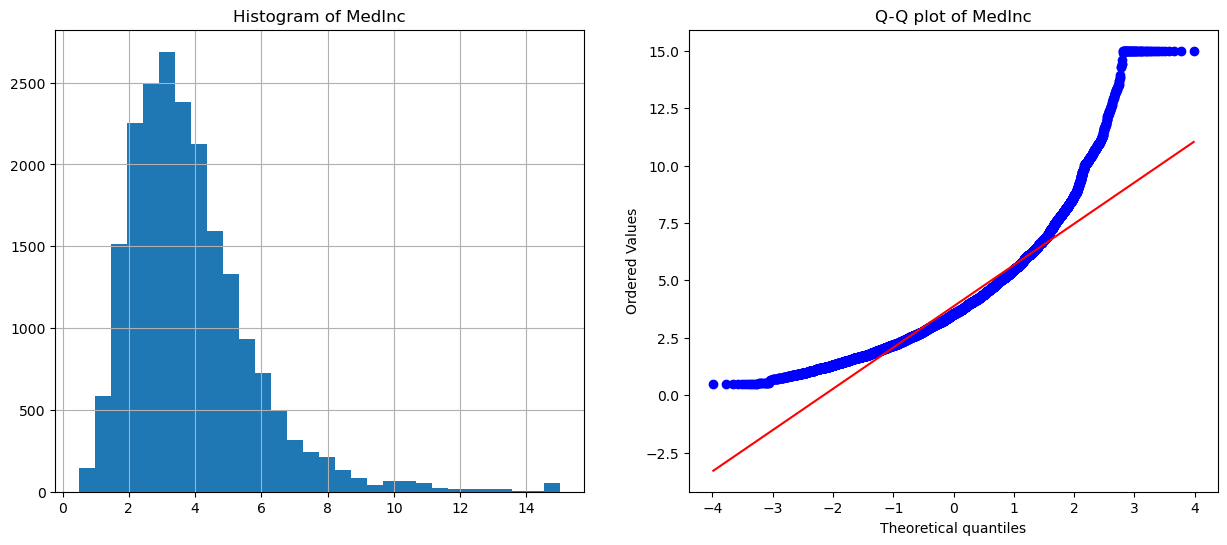

In [67]:
# check original distribution (not included in this recipe of book)

diagnostic_plots(X, "MedInc")

# Box-Cox transformation with SciPy

One variable at a time.

In [68]:
# make a copy of the dataframe where we will store the modified
# variables

X_tf = X.copy()

In [69]:
from scipy.stats import boxcox

X_tf["MedInc"], param = boxcox(X_tf["MedInc"])
print("Optimal λ: ", param)


Optimal λ:  0.090854472181


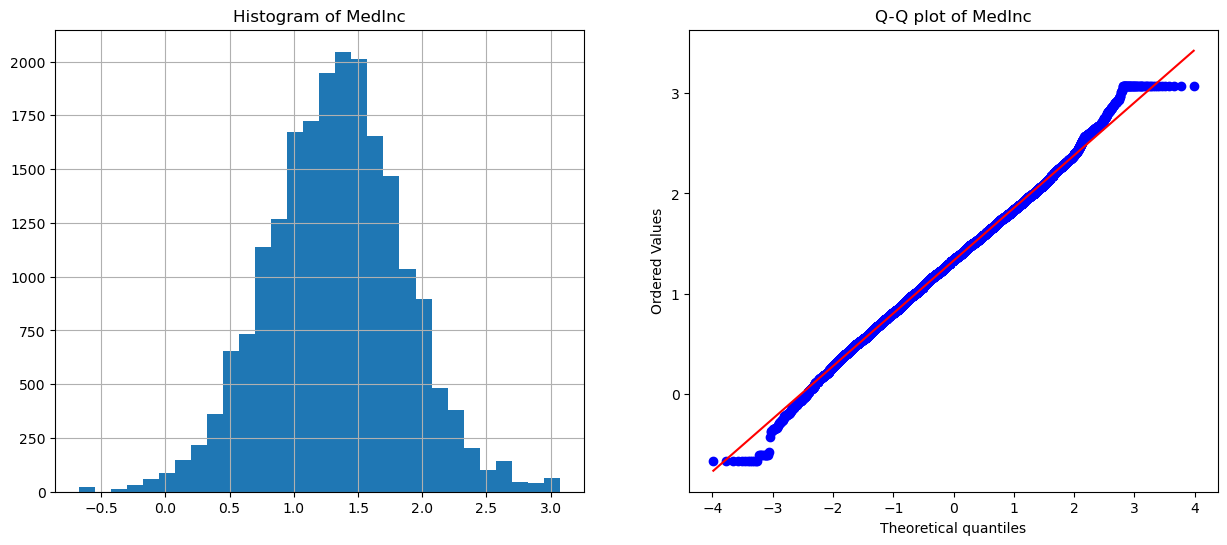

In [70]:
# check original distribution (not included in this recipe of book)

diagnostic_plots(X_tf, "MedInc")

# Yeo-Johnson transformation



In [71]:
import pandas as pd

# for plotting
import matplotlib.pyplot as plt

# for Q-Q plots
import scipy.stats as stats

# the dataset for the demo
from sklearn.datasets import fetch_california_housing

In [72]:
# load the California House price data from Scikit-learn
X, y = fetch_california_housing(return_X_y=True, as_frame=True)

# drop lat and lon
X.drop(labels=["Latitude", "Longitude"], axis=1, inplace=True)

# display top 5 rows
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467


In [73]:
# Plot histogram and Q-Q plots to explore the variable distribution


def diagnostic_plots(df, variable):

    # function to plot a histogram and a Q-Q plot
    # side by side, for a certain variable

    plt.figure(figsize=(15, 6))

    # histogram
    plt.subplot(1, 2, 1)
    df[variable].hist(bins=30)
    plt.title(f"Histogram of {variable}")

    # q-q plot
    plt.subplot(1, 2, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.title(f"Q-Q plot of {variable}")

    plt.show()

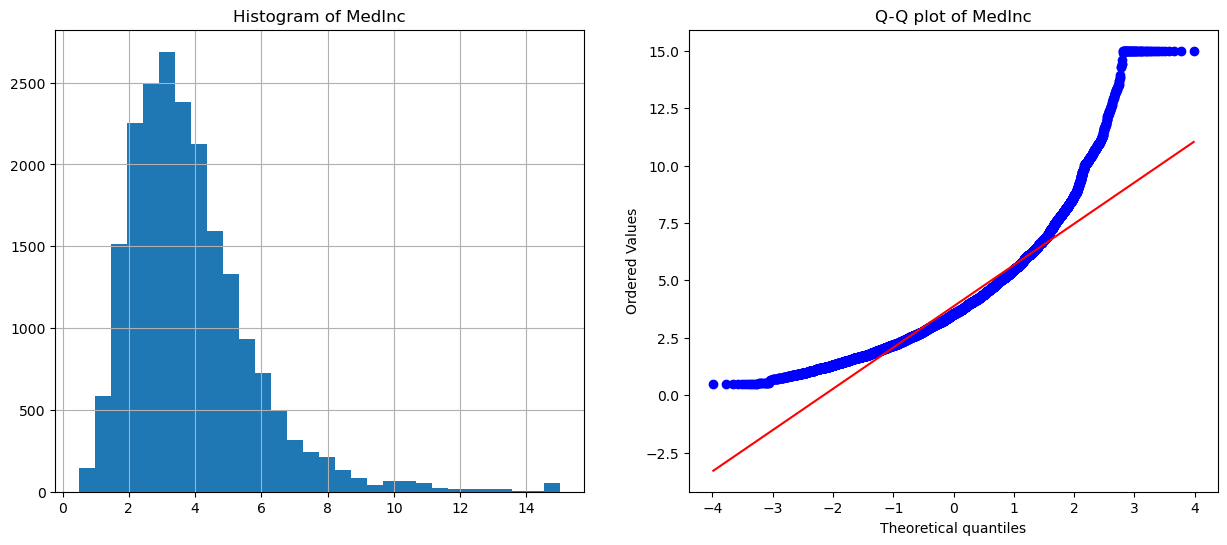

In [74]:
# check original distribution (not included in this recipe of book)

diagnostic_plots(X, "MedInc")

# Yeo-Johnson transformation with SciPy

One variable at a time.

In [75]:
# make a copy of the dataframe where we will store the modified
# variables

X_tf = X.copy()

In [76]:
from scipy.stats import boxcox

X_tf["MedInc"], param = boxcox(X_tf["MedInc"])
print("Optimal λ: ", param)


Optimal λ:  0.090854472181


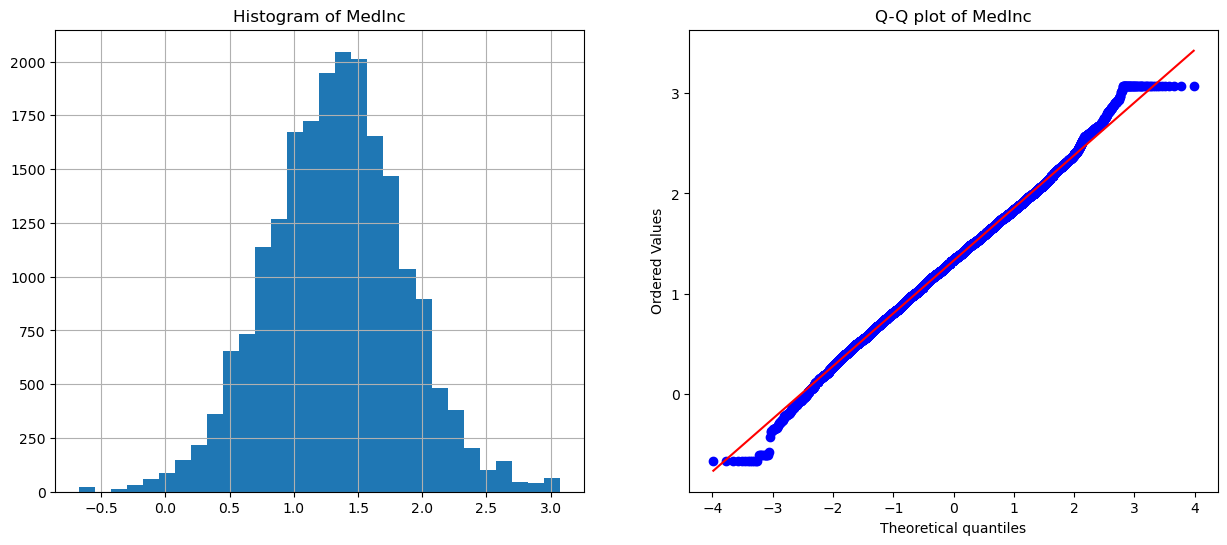

In [77]:
# check original distribution (not included in this recipe of book)

diagnostic_plots(X_tf, "MedInc")

# Arcsin transformation



In [78]:
import numpy as np
import pandas as pd

# for plotting
import matplotlib.pyplot as plt

# for Q-Q plots
import scipy.stats as stats

# dataset for the demo
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

In [79]:
#Load dataset
breast_cancer = load_breast_cancer()
X = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
y = breast_cancer.target

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [80]:
# Separate data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [81]:
variables = [
  'mean compactness',
  'mean concavity',
  'mean concave points',
  'mean fractal dimension',
  'smoothness error',
  'compactness error',
  'concavity error',
  'concave points error',
  'symmetry error',
  'fractal dimension error',
  'worst symmetry',
  'worst fractal dimension']

In [82]:
# make a copy of the data

train_t = X_train.copy()
test_t = X_test.copy()

In [85]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_t[variables] = scaler.fit_transform(train_t[variables])
test_t[variables] = scaler.transform(test_t[variables])


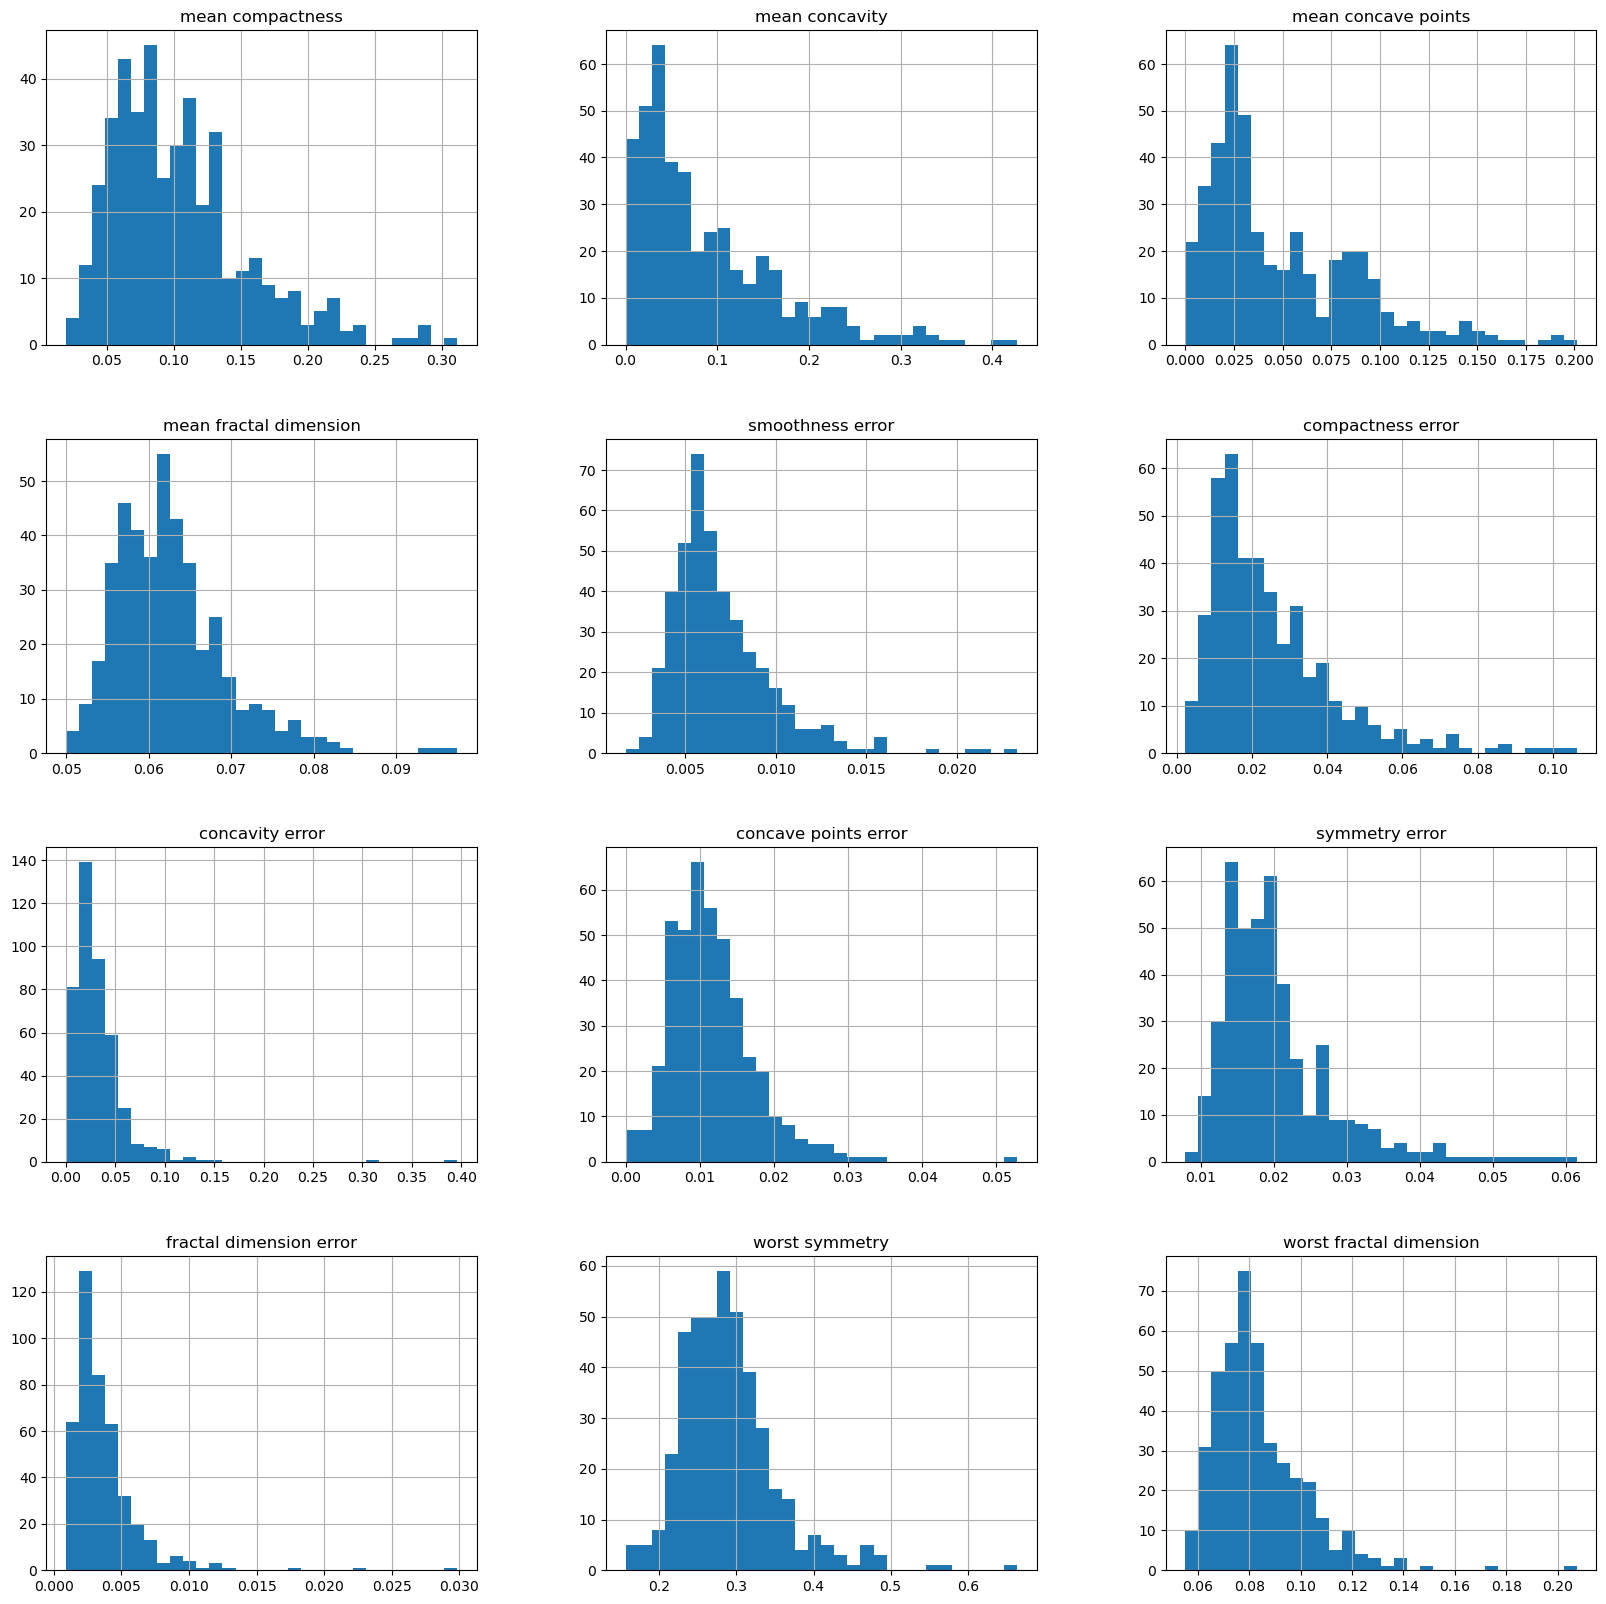

In [86]:
# original variables
X_train[variables].hist(figsize=(20,20), bins=30)
plt.show()

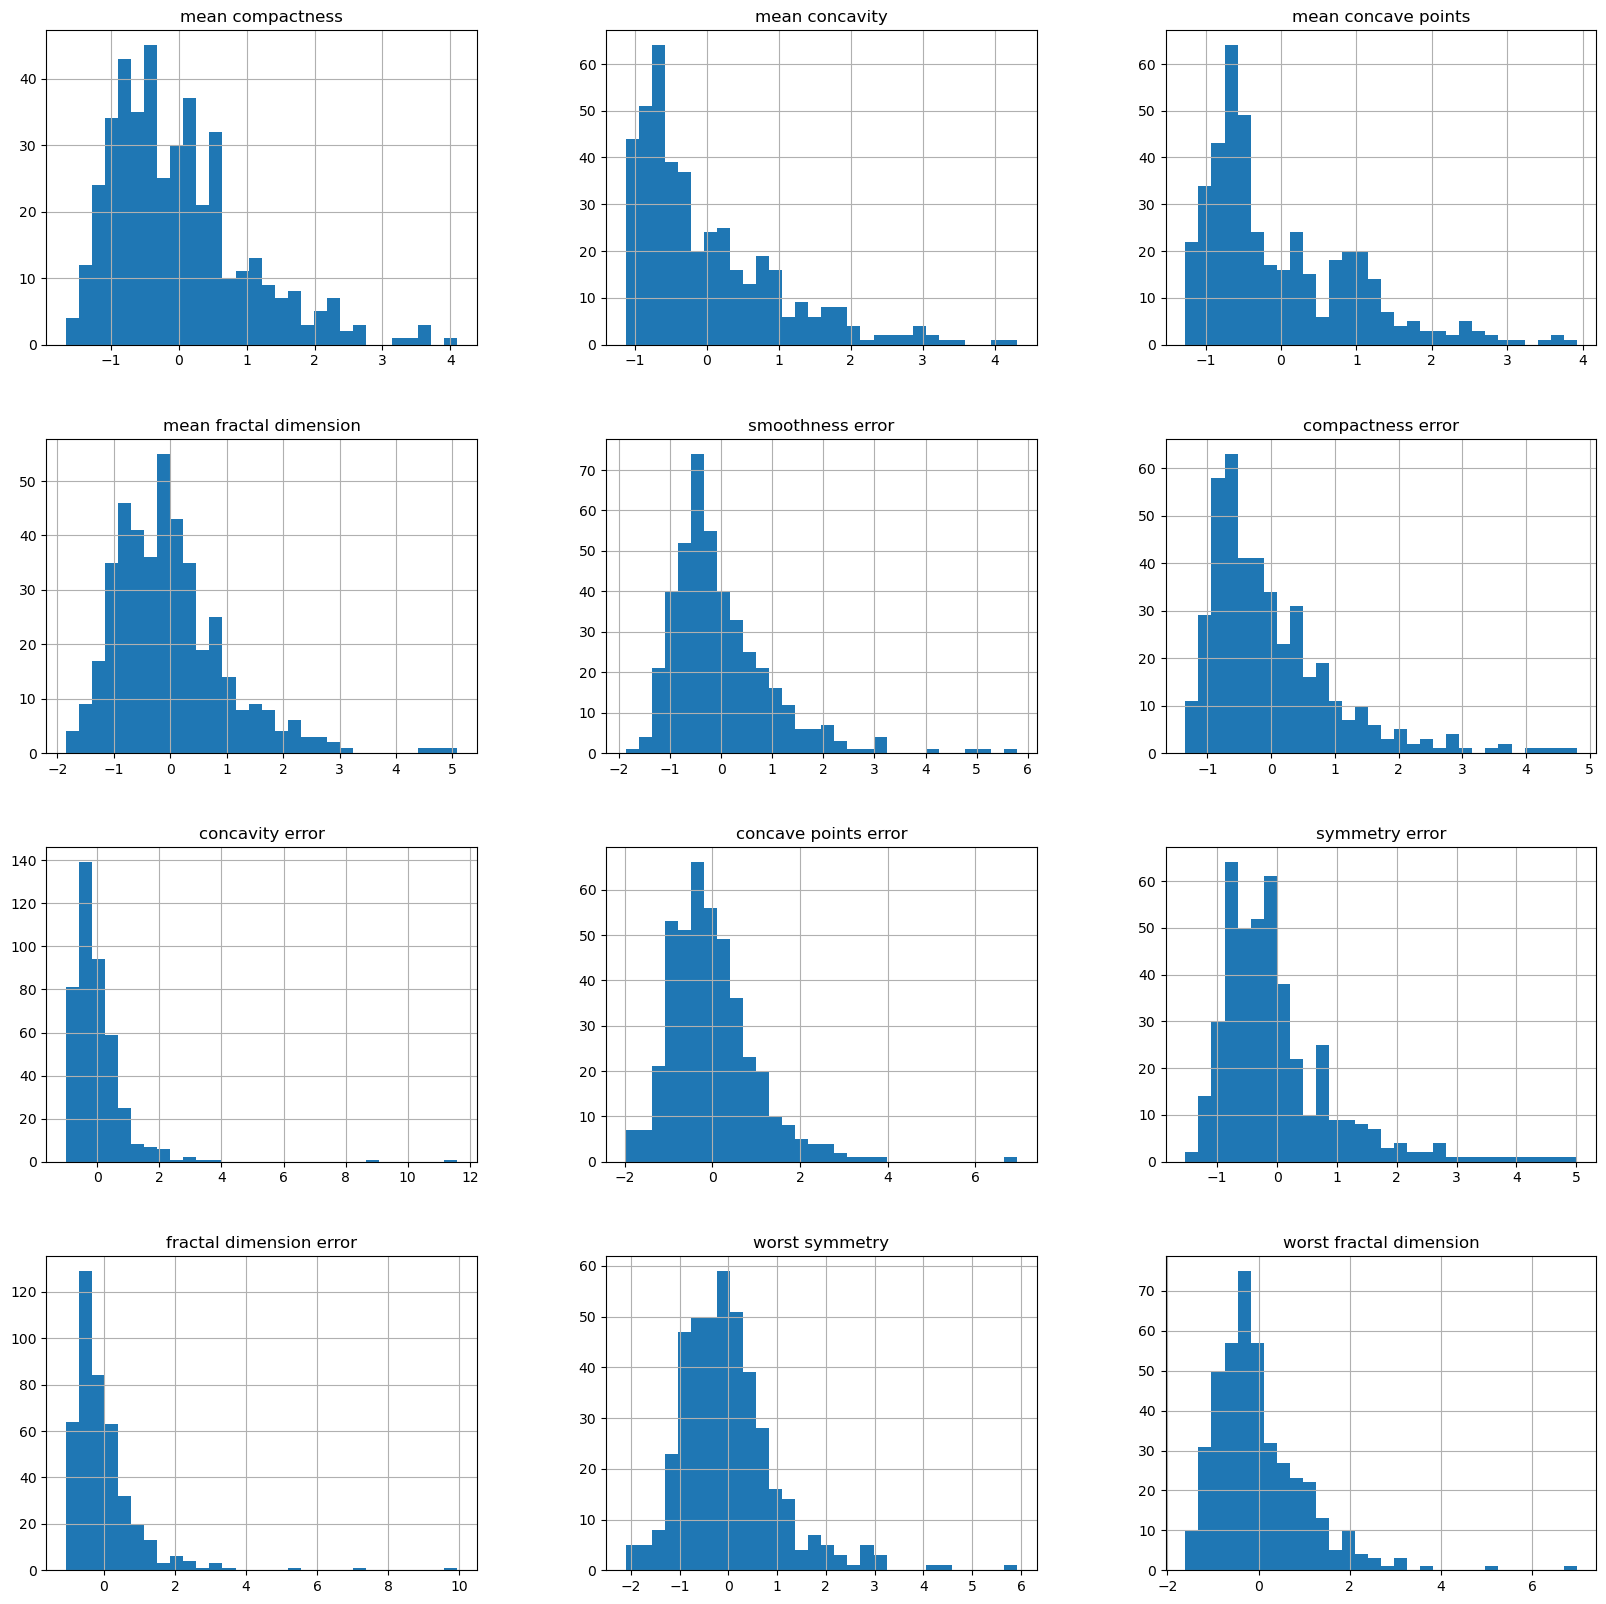

In [87]:
# transformed variable
train_t[variables].hist(figsize=(20,20), bins=30)
plt.show()

In [88]:
# Load up california housing data set and apply at least 3 different feature scaling / transformation methods to the features.
# Plot the original features and the modified features

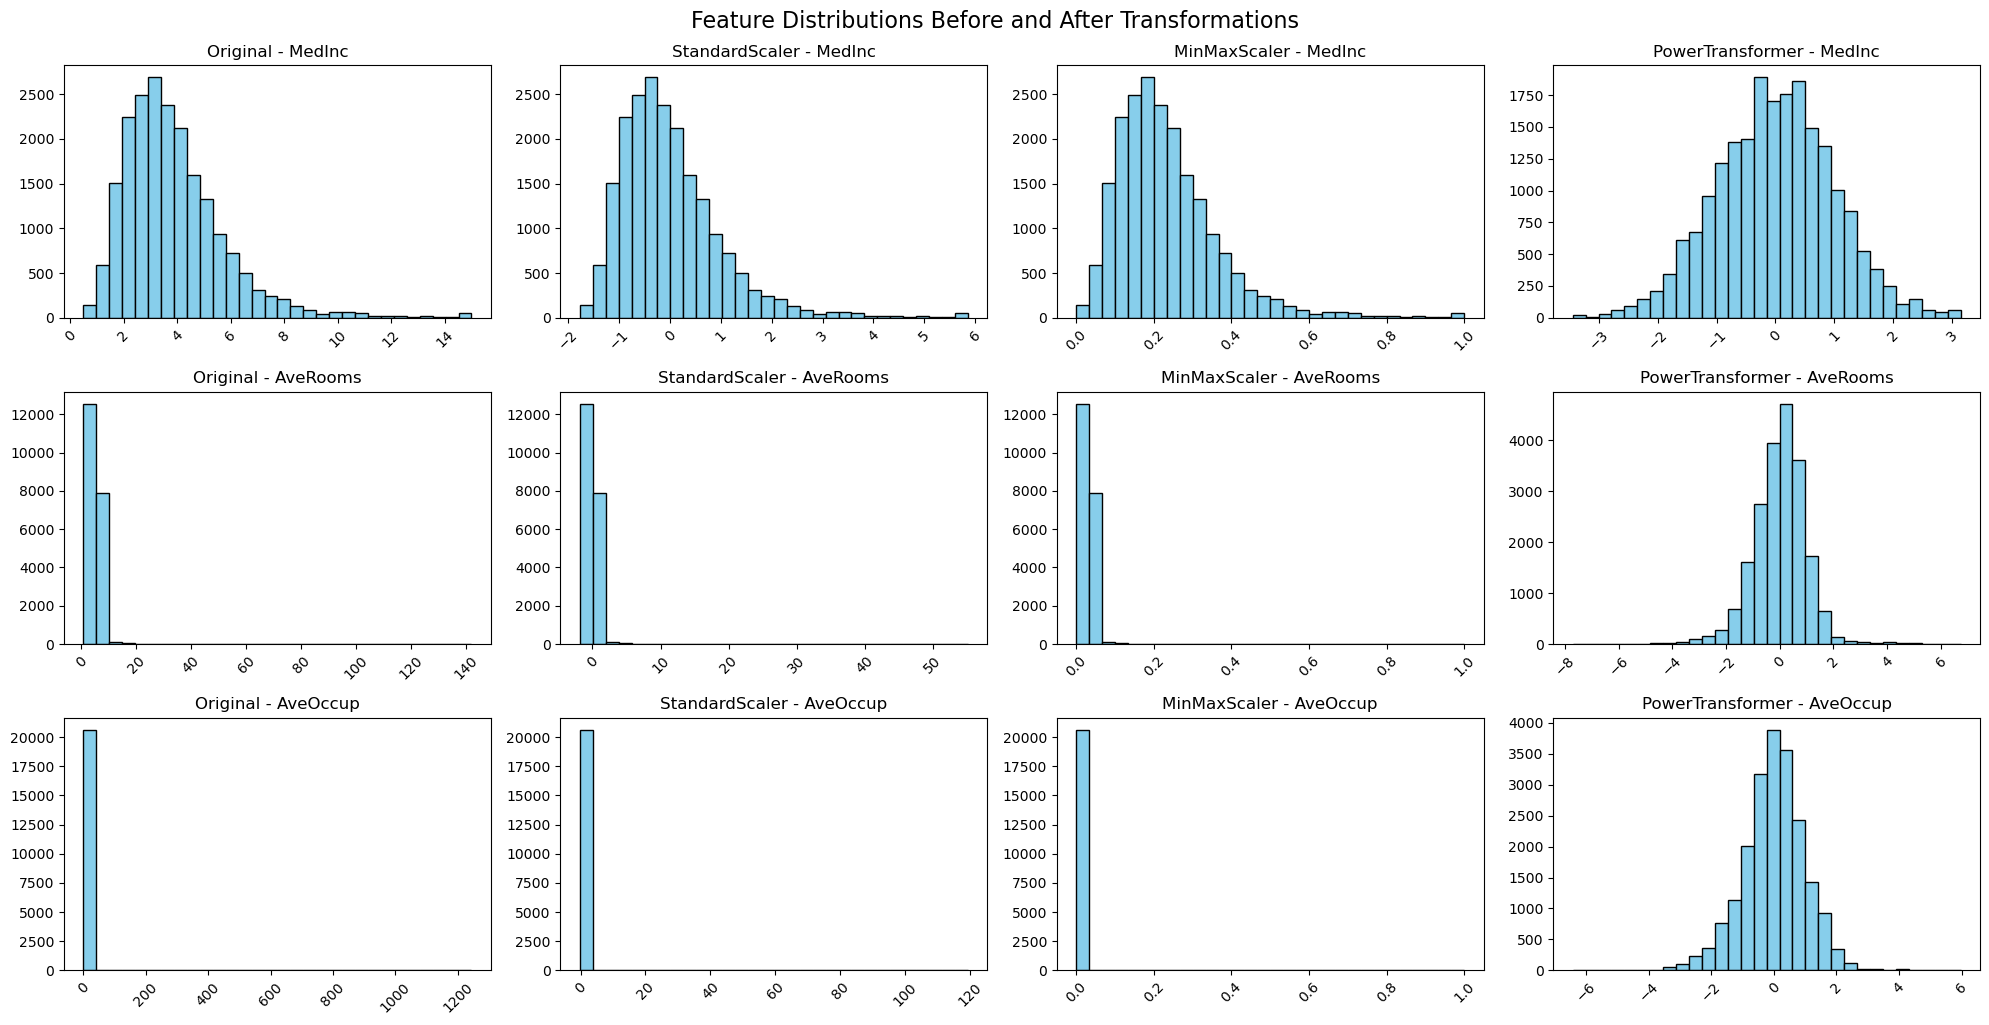

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer

# Load the California housing dataset
data = fetch_california_housing(as_frame=True)
df = data.frame

# Select some features for visualization
features = ["MedInc", "AveRooms", "AveOccup"]

# 1. Standard Scaling
standard_scaler = StandardScaler()
df_standard = df.copy()
df_standard[features] = standard_scaler.fit_transform(df_standard[features])

# 2. Min-Max Scaling
minmax_scaler = MinMaxScaler()
df_minmax = df.copy()
df_minmax[features] = minmax_scaler.fit_transform(df_minmax[features])

# 3. Power Transform (Yeo-Johnson handles zero/negative values)
power_transformer = PowerTransformer(method='yeo-johnson')
df_power = df.copy()
df_power[features] = power_transformer.fit_transform(df_power[features])

# Plotting original and transformed features
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 10))
scaling_methods = ['Original', 'StandardScaler', 'MinMaxScaler', 'PowerTransformer']
datasets = [df, df_standard, df_minmax, df_power]

for i, feature in enumerate(features):
    for j, dataset in enumerate(datasets):
        axes[i, j].hist(dataset[feature], bins=30, color='skyblue', edgecolor='black')
        axes[i, j].set_title(f"{scaling_methods[j]} - {feature}")
        axes[i, j].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.suptitle("Feature Distributions Before and After Transformations", fontsize=16, y=1.02)
plt.show()
